<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Flecha_y_cojinte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FLECHA Y COJINTE**

Se usan dos métodos vistos en clase:

1. Método de las 12 uniformes.
2. Método de Box-Muller.


# DATOS DEL PROBLEMA

Se tiene:

$$X_1 \sim N(1.5,0.0016)$$

$$X_2 \sim N(1.48,0.0009)$$

donde $X_1$ representa el diámetro del cojinete y $X_2$ representa el diámetro de la flecha.

Teniendo los datos podemos solo implementarlos en el programa realizado en clase.

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

#Simulación con el Metodo de las 12 uniformes

Permite aproximar una variable aleatoria normal estándar a partir de variables aleatorias uniformes.

Sea:

$$R_i\sim U(0,1), \qquad i=1,2,\dots,12$$

Entonces, por el Teorema Central del Límite, se puede aproximar una variable normal estándar mediante:

$$Z=\sum_{i=1}^{12}R_i-6$$

donde aproximadamente:

$$Z\sim N(0,1)$$

Una vez generada la variable normal estándar $Z$, se transforma a una normal general mediante:

$$X=\mu+\sigma Z$$

En este problema se tiene:

$$X_1\sim N(1.5,0.0016)$$

$$X_2\sim N(1.48,0.0009)$$

Por lo tanto, las desviaciones estándar son:

$$\sigma_1=\sqrt{0.0016}=0.04$$

$$\sigma_2=\sqrt{0.0009}=0.03$$

Así, las variables simuladas quedan dadas por:

$$X_1=1.5+0.04Z_1$$

$$X_2=1.48+0.03Z_2$$

donde $Z_1$ y $Z_2$ son normales estándar aproximadas generadas con el método de las 12 uniformes.

Finalmente, se considera que existe interferencia cuando el diámetro de la flecha es mayor que el diámetro del cojinete, es decir:

$X_2>X_1$

La probabilidad simulada de interferencia se calcula como:
$$\hat{p}=\frac{\text{número de interferencias}}{\text{número total de simulaciones}}$$

In [2]:
def gaussiana(mu, sigma, n):
  #que argumentos necesitan la funcion media, ñu, varianza, desviacion estandar
    muestra = []   #lista vacia
    #necesitamos una sumatoria
    for i in range(n):
        suma = 0
        for j in range(12):
            u = r.random()
            suma = suma + u
        x = mu + sigma * (suma - 6)
        muestra.append(x)
    return muestra

In [3]:
def simulacion1(n):
  mu1 = 1.5
  sigma1 = np.sqrt(0.0016)
  mu2 = 1.48
  sigma2 = np.sqrt(0.0009)

  X1 = gaussiana(mu1, sigma1, n)
  X2 = gaussiana(mu2, sigma2, n)

  contador = 0
  for i in range(n):
      if X2[i] > X1[i]:
          contador = contador + 1
  p = contador / n

  return contador,p,X1, X2

n = 8677
p_sim,inter,X1,X2 = simulacion1(n)
print("Probabilidad simulada:",inter)
print("Número de interferencias:",p_sim)


Probabilidad simulada: 0.3456263685605624
Número de interferencias: 2999


In [4]:
M = simulacion1(8677)

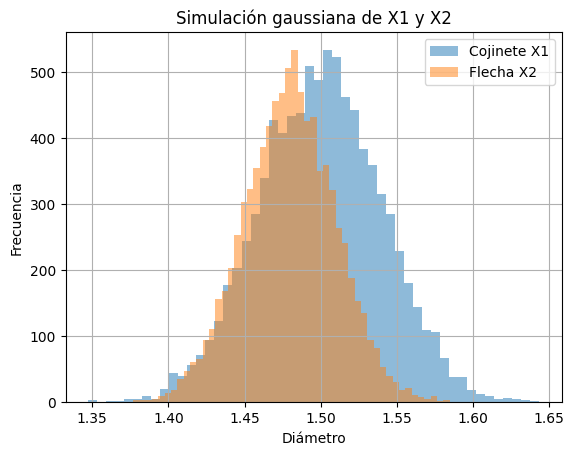

In [5]:
plt.hist(X1, bins=50, alpha=0.5, label="Cojinete X1")
plt.hist(X2, bins=50, alpha=0.5, label="Flecha X2")
plt.title("Simulación gaussiana de X1 y X2")
plt.xlabel("Diámetro")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

# Simulación con el método de Box-Muller

Este método genera variables normales estándar a partir de dos variables uniformes independientes.

Sean:
$$U_1,U_2\sim U(0,1)$$

Entonces:
$$Z_1=\sqrt{-2\ln(U_1)}*\cos(2\pi U_2)$$
$$Z_2=\sqrt{-2\ln(U_1)}*\sin(2\pi U_2)$$

donde:
$$Z_1,Z_2\sim N(0,1)$$

Luego transformamos a una normal general:
$$X=\mu+\sigma Z$$

Para este problema:
$$X_1=1.5+0.04Z_1$$
$$X_2=1.48+0.03Z_2$$
porque:
$$\sigma_1=\sqrt{0.0016}=0.04$$
$$\sigma_2=\sqrt{0.0009}=0.03$$

Finalmente, hay interferencia cuando:
$$X_2>X_1$$

y la probabilidad simulada se calcula mediante:
$$\hat{p}=
\frac{\text{número de interferencias}}
{\text{número total de simulaciones}}$$


In [6]:
def muller(mu,sigma,n):
    muestra_1 = []
    for i in range (n):
        u1 = r.random()
        u2 = r.random()
        z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)

        x_m = mu + sigma * z1
        y_m = mu + sigma * z2


        muestra_1.append(x_m)
        muestra_1.append(y_m)
    return muestra_1

In [7]:
def simulacion2(n):
  mu_1 = 1.5
  sigma_1 = np.sqrt(0.0016)
  mu_2 = 1.48
  sigma_2 = np.sqrt(0.0009)

  X_1 = muller(mu_1, sigma_1, n)
  X_2 = muller(mu_2, sigma_2, n)

  contador_2 = 0

  for i in range(n):
      if X2[i] > X1[i]:
          contador_2 = contador_2 + 1
  p_2 = contador_2 / n

  return contador_2,p_2,X_1, X_2

In [8]:
n = 8677
p_sim_2,inter_2,X_1,X_2 = simulacion2(n)
print("Probabilidad simulada:",inter_2)
print("Número de interferencias:",p_sim_2)

Probabilidad simulada: 0.3456263685605624
Número de interferencias: 2999


In [9]:
N = simulacion2(8677)

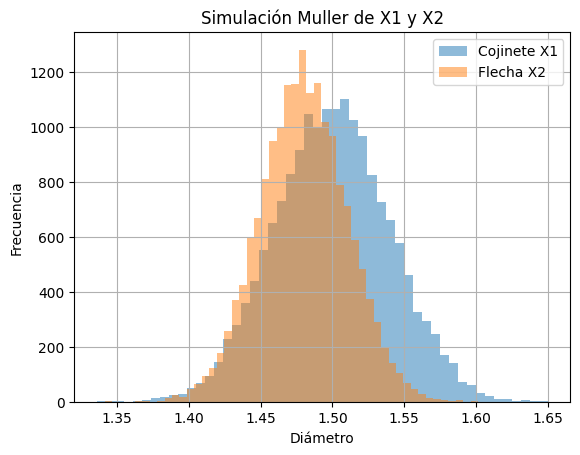

In [10]:
plt.hist(X_1, bins=50, alpha=0.5, label="Cojinete X1")
plt.hist(X_2, bins=50, alpha=0.5, label="Flecha X2")
plt.title("Simulación Muller de X1 y X2")
plt.xlabel("Diámetro")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

Por ultimo calculamos la solucion analitica

## Solución analítica

Hay interferencia cuando:

$$X_2>X_1$$

Definimos:

$$D=X_1-X_2$$

Entonces hay interferencia si:

$$D<0$$

Como $X_1$ y $X_2$ son normales independientes, $D$ también es normal.


In [11]:
import math
def Phi(z):
    return 0.5 * (1 + math.erf(z / np.sqrt(2)))

In [12]:
mu1 = 1.5
var1 = 0.0016

mu2 = 1.48
var2 = 0.0009

sigma1 = np.sqrt(var1)
sigma2 = np.sqrt(var2)

print("DATOS DEL PROBLEMA")
print("Media de X1:", mu1)
print("Varianza de X1:", var1)
print("Desviación estándar de X1:", sigma1)

print("\nMedia de X2:", mu2)
print("Varianza de X2:", var2)
print("Desviación estándar de X2:", sigma2)
mu_D = mu1 - mu2
var_D = var1 + var2
sigma_D = np.sqrt(var_D)
# Estandarizamos:
# P(D < 0) = P((D - mu_D)/sigma_D < (0 - mu_D)/sigma_D)

z = (0 - mu_D) / sigma_D

p_analitica = Phi(z)

print("\nSOLUCIÓN ANALÍTICA")
print("Media de D = X1 - X2:", mu_D)
print("Varianza de D:", var_D)
print("Desviación estándar de D:", sigma_D)
print("Valor z:", z)
print("Probabilidad analítica de interferencia:", p_analitica)

DATOS DEL PROBLEMA
Media de X1: 1.5
Varianza de X1: 0.0016
Desviación estándar de X1: 0.04

Media de X2: 1.48
Varianza de X2: 0.0009
Desviación estándar de X2: 0.03

SOLUCIÓN ANALÍTICA
Media de D = X1 - X2: 0.020000000000000018
Varianza de D: 0.0025
Desviación estándar de D: 0.05
Valor z: -0.40000000000000036
Probabilidad analítica de interferencia: 0.3445782583896757


## Número necesario de simulaciones INCISO B

Para estimar una proporción con error máximo $E=0.01$ y nivel de seguridad del 95%, usamos:

$$n=\frac{z^2p(1-p)}{E^2}$$


In [13]:
E = 0.01
z_95 = 1.96

n = (z_95**2 * p_analitica * (1 - p_analitica)) / E**2
n = math.ceil(n)

print("\nNÚMERO NECESARIO DE SIMULACIONES")
print("Error máximo permitido:", E)
print("Nivel de seguridad: 95%")
print("Número mínimo de simulaciones:", n)


NÚMERO NECESARIO DE SIMULACIONES
Error máximo permitido: 0.01
Nivel de seguridad: 95%
Número mínimo de simulaciones: 8677
